In [1]:
import pandas as pd 
import numpy as np
# import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Load dataset
df = pd.read_csv('ecommerce_customer_churn_large.csv')

In [4]:
# Drop irrelevant unique identifier columns for behavioral analysis
analysis_df = df.drop(columns=['customer_id'])

In [5]:
# Segregate data types
num_cols = analysis_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('churn')  # Treat churn explicitly as binary target
cat_cols = analysis_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical variables: {num_cols}")
print(f"Categorical variables: {cat_cols}")

Numerical variables: ['age', 'tenure_months', 'avg_order_value', 'total_orders', 'last_purchase_days_ago', 'support_tickets']
Categorical variables: ['gender', 'city', 'subscription_type']


## Univariate Analysis

- 1. Univariate Categorical Grid Analysis

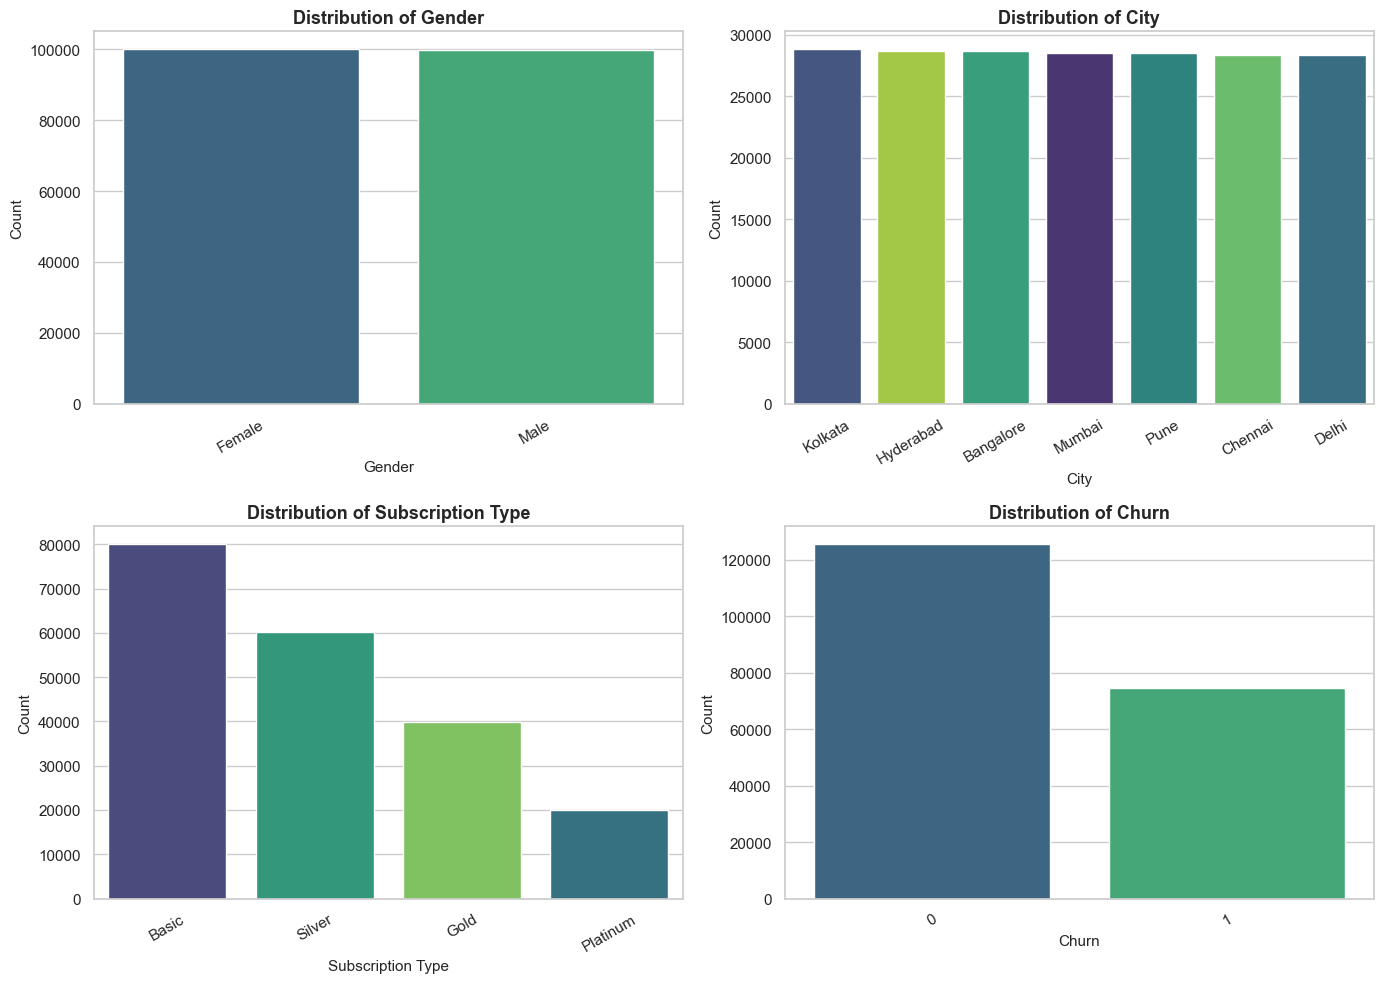

In [6]:
# Configure global aesthetics
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for all categorical columns + target variable
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

all_cat = cat_cols + ['churn']
for i, col in enumerate(all_cat):
    order = analysis_df[col].value_counts().index
    
    # Corrected hue handling to stop Seaborn palette warnings
    sns.countplot(
        data=analysis_df, 
        x=col, 
        order=order, 
        hue=col, 
        palette='viridis', 
        dodge=False, 
        ax=axes[i]
    )
    
    # Safely clear out redundant auto-generated legends
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()
        
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col.replace("_", " ").title(), fontsize=11)
    axes[i].set_ylabel('Count', fontsize=11)
    
    # Safe label rotation strategy preventing any Matplotlib UserWarnings
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('univariate_categorical_plots.png', dpi=150)
plt.show()  # <--- Forces the chart to draw on your screen/notebook

- 2. Univariate Numerical Grid Analysis

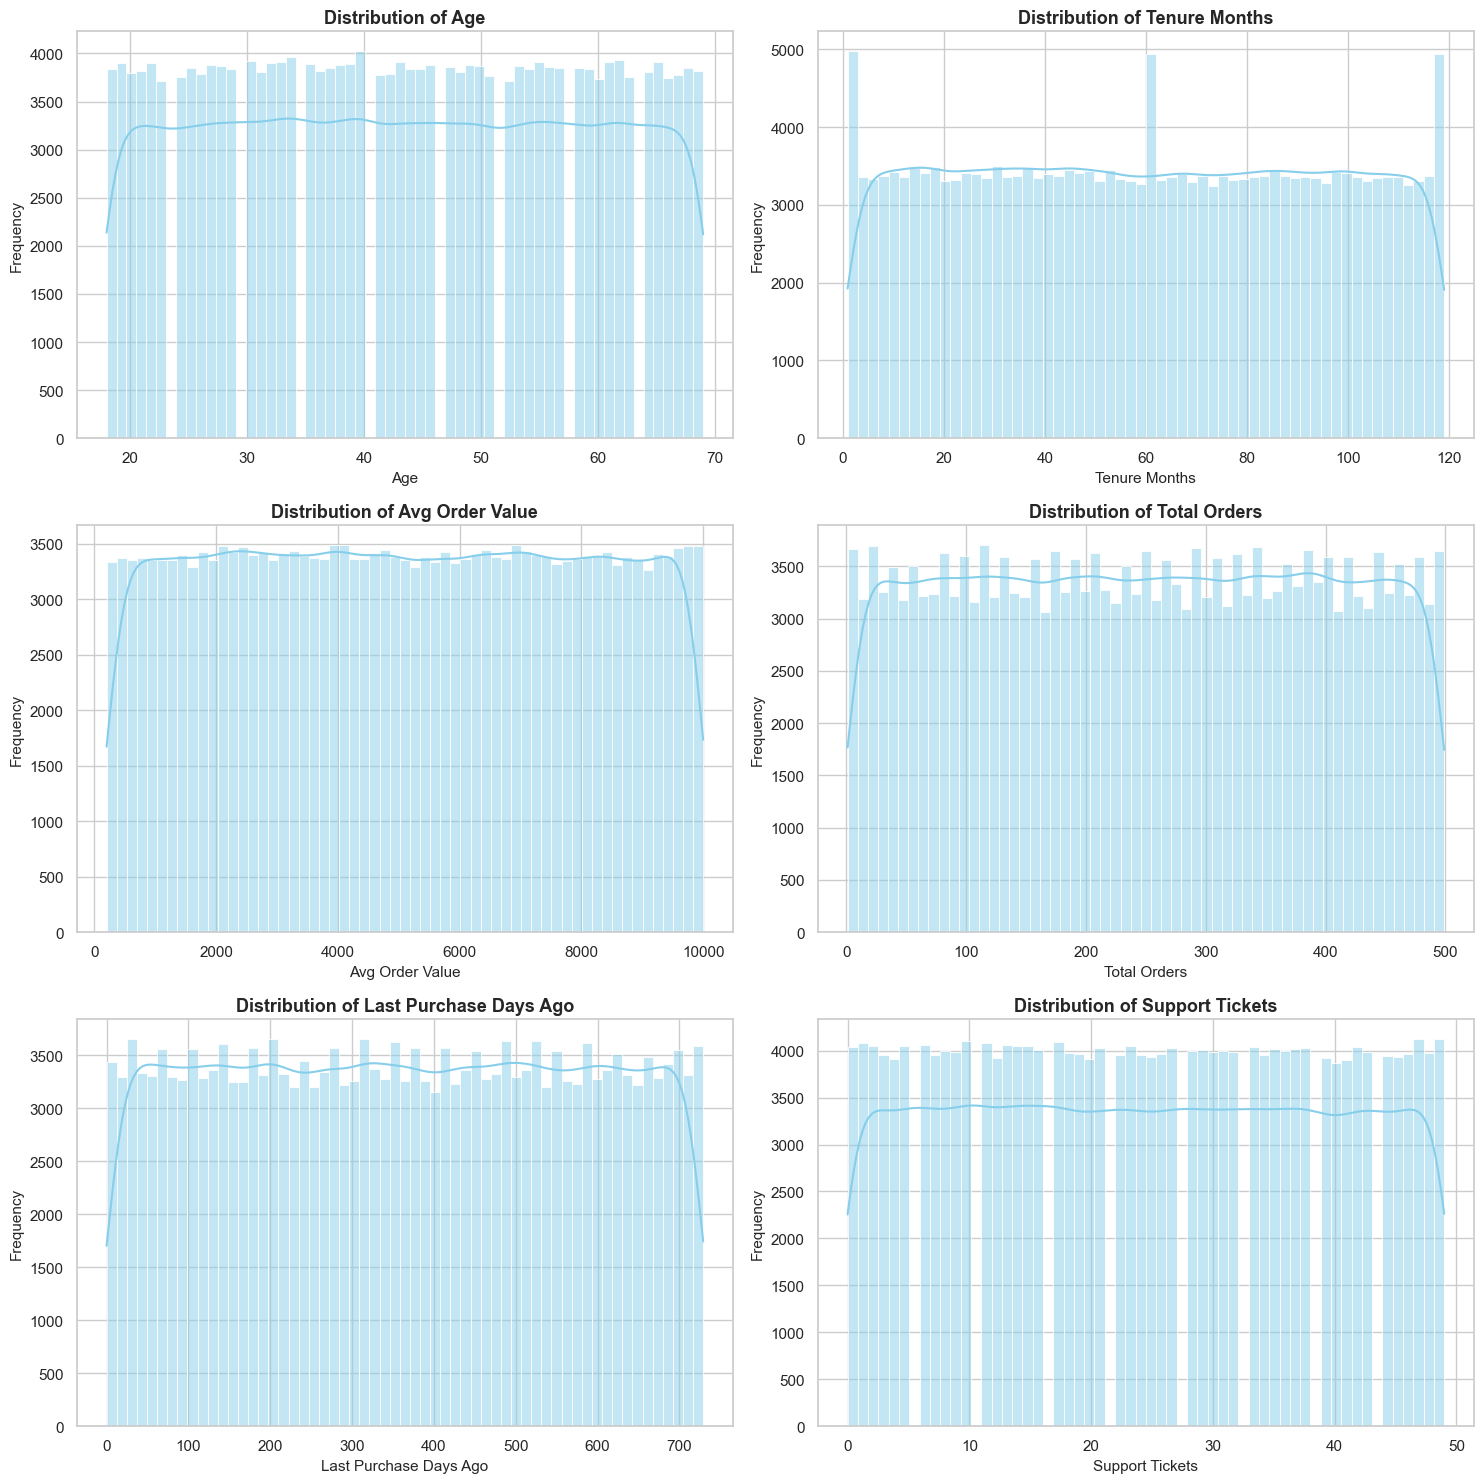

In [7]:
# Create a 3x2 grid for numerical metrics
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=analysis_df, 
        x=col, 
        kde=True, 
        color='skyblue', 
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col.replace("_", " ").title(), fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)

plt.tight_layout()
plt.savefig('univariate_numerical_plots.png', dpi=150)
plt.show()

## Bivariate Analysis

- 1. Bivariate Analysis: Categorical Tiers vs. Churn Rate

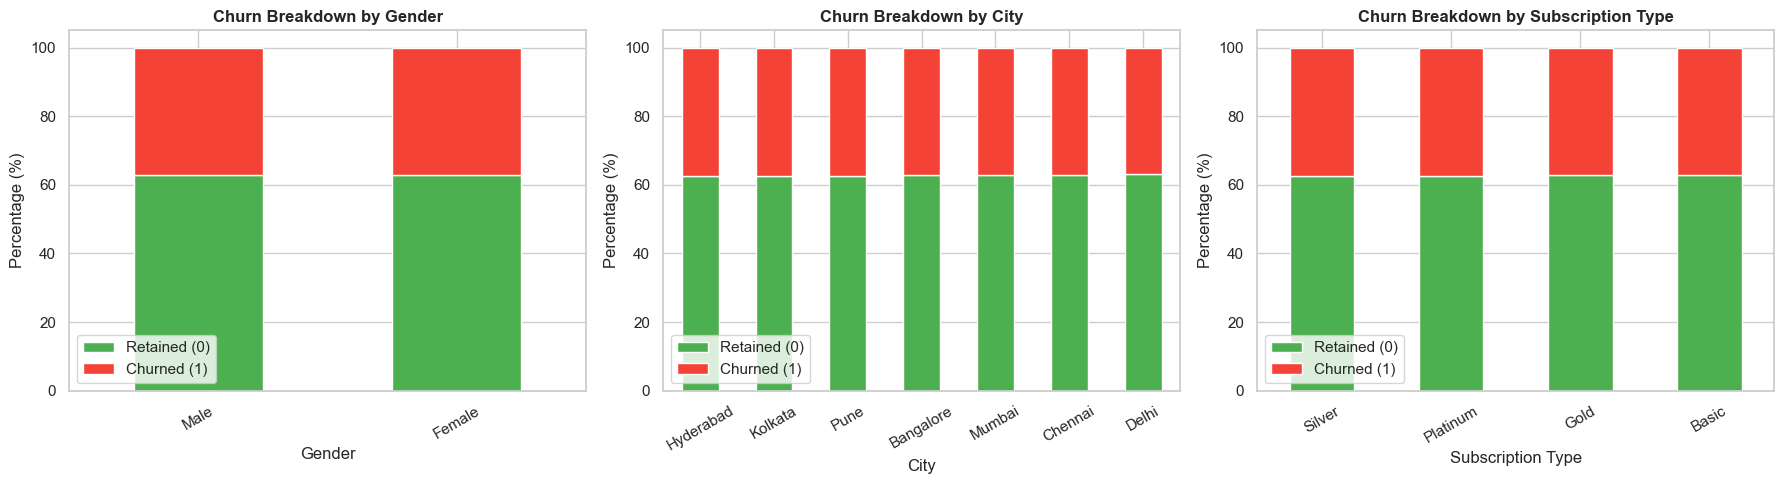

In [8]:
# Create a 1x3 grid side-by-side to track proportions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    cross_tab = pd.crosstab(analysis_df[col], analysis_df['churn'], normalize='index') * 100
    cross_tab = cross_tab.sort_values(by=1, ascending=False)
    
    cross_tab.plot(
        kind='bar', 
        stacked=True, 
        color=['#4caf50', '#f44336'], 
        ax=axes[i]
    )
    
    axes[i].set_title(f'Churn Breakdown by {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Retained (0)', 'Churned (1)'], loc='lower left')

plt.tight_layout()
plt.savefig('bivariate_categorical_vs_churn.png', dpi=150)
plt.show()

- 2. Bivariate Analysis: Numerical Columns vs. Churn Status

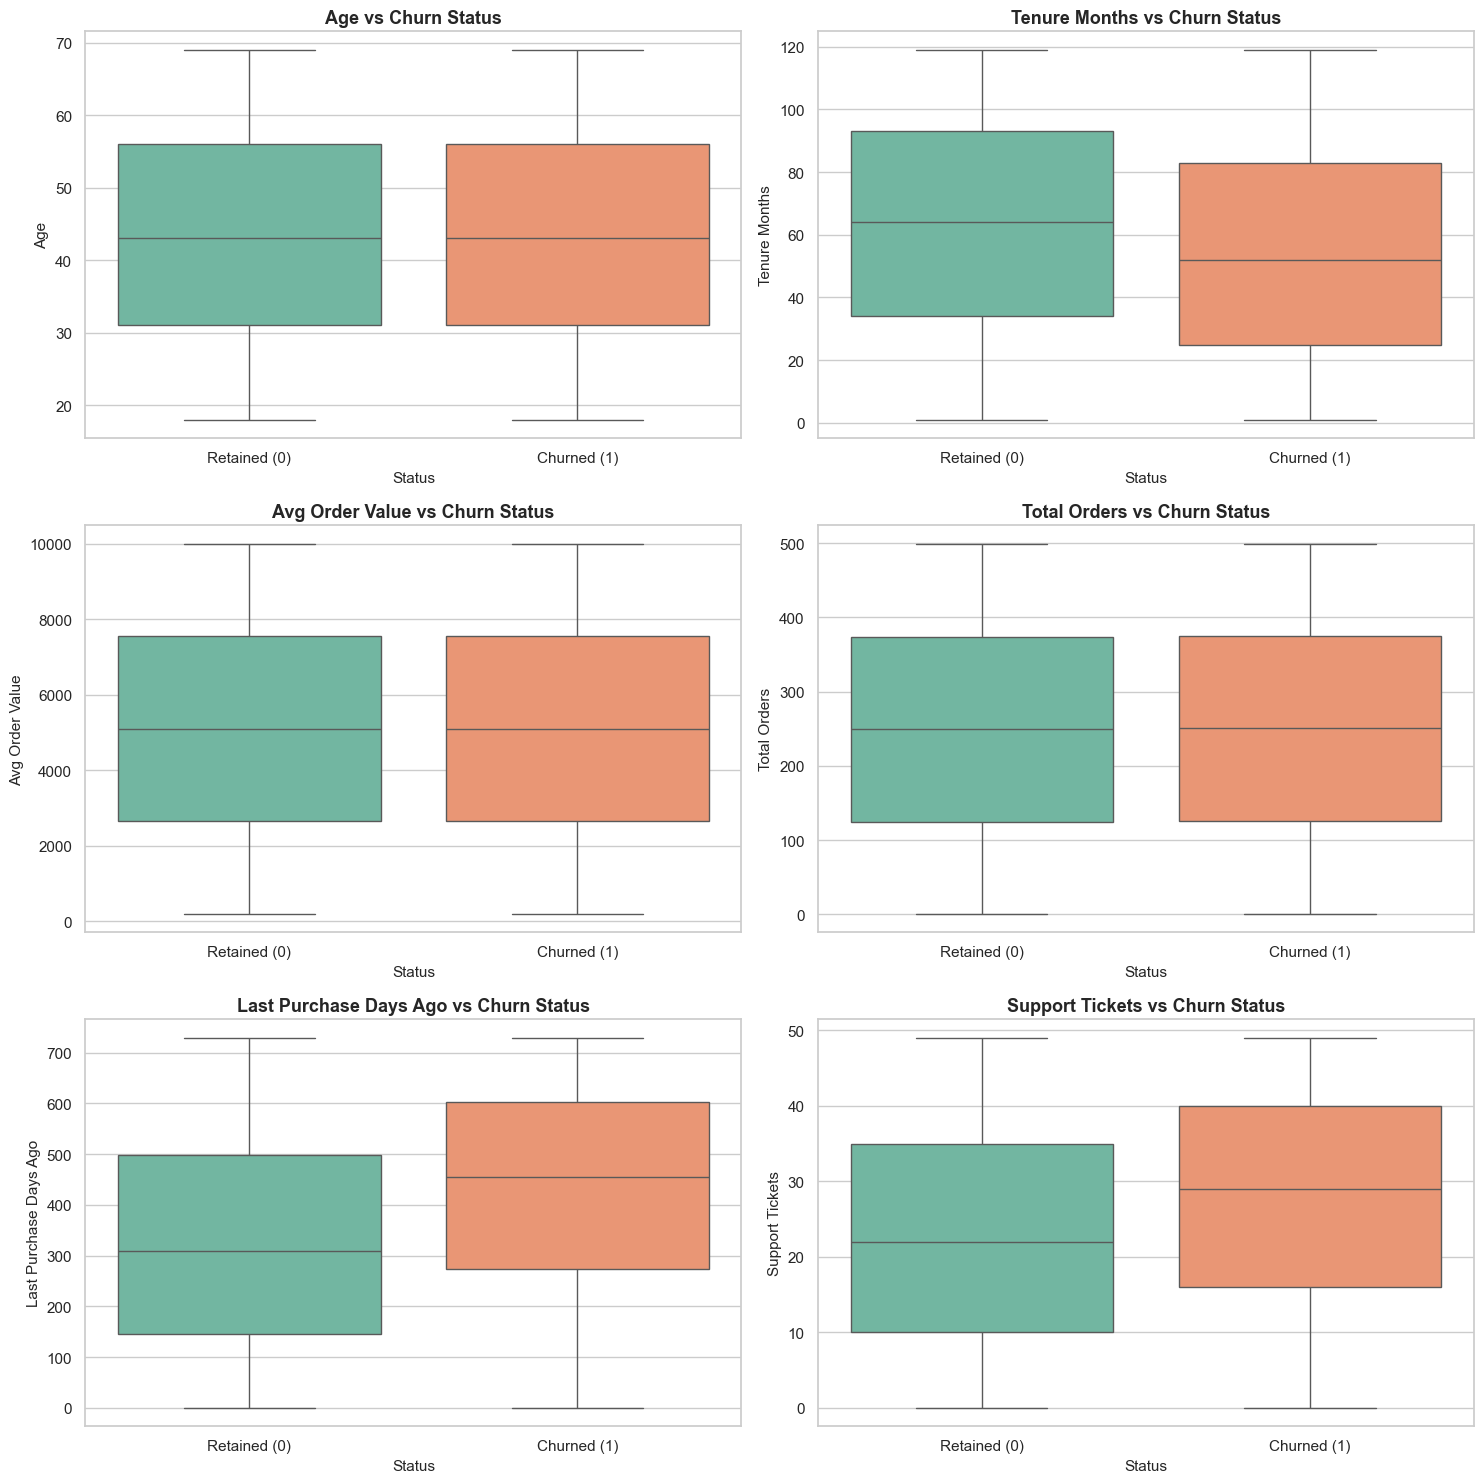

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=analysis_df, 
        x='churn', 
        y=col, 
        hue='churn', 
        palette='Set2', 
        dodge=False, 
        ax=axes[i]
    )
    
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()
        
    # FIXING THE WARNING HERE:
    axes[i].set_xticks([0, 1], labels=['Retained (0)', 'Churned (1)'])
    axes[i].set_title(f'{col.replace("_", " ").title()} vs Churn Status', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Status', fontsize=11)
    axes[i].set_ylabel(col.replace("_", " ").title(), fontsize=11)

plt.tight_layout()
plt.savefig('bivariate_numerical_vs_churn_fixed.png', dpi=150)
plt.show()

## Multivariate Analysis

- Multivariate Analysis: Correlation Linear Matrix

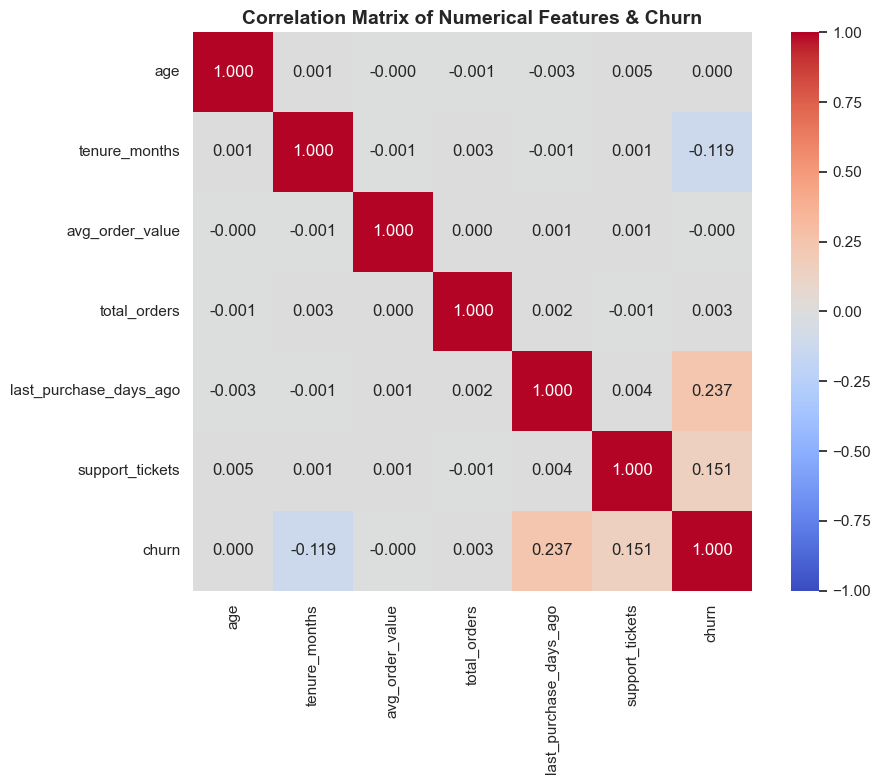

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

# Join targets & continuous vectors to map dependencies
corr_matrix = analysis_df[num_cols + ['churn']].corr(method='pearson')

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".3f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True, 
    ax=ax
)

ax.set_title('Correlation Matrix of Numerical Features & Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('multivariate_correlation_heatmap.png', dpi=150)
plt.show()

In [11]:
import urllib
import sys
from sqlalchemy import create_engine

def migrate_to_sql_server(csv_file_path, table_name):
    # ==========================================
    # STEP 1: EXTRACT THE CSV DATA
    # ==========================================
    print("⏳ Step 1: Loading CSV data into Python DataFrame...")
    try:
        df = pd.read_csv(csv_file_path)
        print(f"✅ Success: Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
    except Exception as e:
        print(f"❌ Error loading CSV: {e}")
        sys.exit(1)

    # ==========================================
    # STEP 2: CLEANSE & TRANSFORM SCHEMA
    # ==========================================
    print("⏳ Step 2: Optimizing column names for SQL Server schemas...")
    # Formats headers to lowercase and replaces spaces with underscores
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^\w]', '', regex=True)

    # ==========================================
    # STEP 3: CONSTRUCT SQL SERVER CONNECTION
    # ==========================================
    print("⏳ Step 3: Connecting to your SQL Server instance...")
    
    # 🎯 YOUR EXACT SERVER SPECIFICATIONS APPLIED HERE
    SERVER_NAME = r'LAPTOP-A2FG8CBK\SQLEXPRESS'  # Added 'r' to safely handle the backslash
    DATABASE_NAME = 'EcommerceDB'               # Replace with your actual database name in SSMS
    DRIVER_NAME = 'ODBC Driver 17 for SQL Server'
    
    # Using Windows Authentication (No password required)
    connection_params = f"DRIVER={{{DRIVER_NAME}}};SERVER={SERVER_NAME};DATABASE={DATABASE_NAME};Trusted_Connection=yes;"

    try:
        # URL-encode the parameters string so the backslash and tracking tokens don't break the connection string
        quoted_params = urllib.parse.quote_plus(connection_params)
        connection_string = f"mssql+pyodbc:///?odbc_connect={quoted_params}"
        
        # Initialize the engine with fast_executemany=True for high-speed uploads
        engine = create_engine(connection_string, fast_executemany=True)
        print(f"✅ Success: Connected to Server '{SERVER_NAME}'")
    except Exception as e:
        print(f"❌ Database connection failed: {e}")
        print("\n💡 Analyst Tip: Verify that 'EcommerceDB' exists in your SSMS and that ODBC Driver 17 is installed.")
        sys.exit(1)

    # ==========================================
    # STEP 4: BULK INGESTION STREAMING
    # ==========================================
    print(f"⏳ Step 4: Streaming records into SQL table '{table_name}'...")
    try:
        df.to_sql(
            name=table_name,
            con=engine,
            if_exists='replace', # Drops table if it exists and creates a fresh one automatically
            index=False,
            chunksize=25000      # Batches data to keep execution fast and memory-safe
        )
        print(f"🎉 SUCCESS: Data fully loaded into '{SERVER_NAME}.{DATABASE_NAME}.dbo.{table_name}' in seconds!")
    except Exception as e:
        print(f"❌ Critical database write failure: {e}")

if __name__ == "__main__":
    CSV_PATH = 'ecommerce_customer_churn_large.csv'
    TARGET_TABLE = 'customer_churn'
    
    migrate_to_sql_server(CSV_PATH, TARGET_TABLE)

⏳ Step 1: Loading CSV data into Python DataFrame...
✅ Success: Loaded 200000 rows and 11 columns.
⏳ Step 2: Optimizing column names for SQL Server schemas...
⏳ Step 3: Connecting to your SQL Server instance...
✅ Success: Connected to Server 'LAPTOP-A2FG8CBK\SQLEXPRESS'
⏳ Step 4: Streaming records into SQL table 'customer_churn'...
🎉 SUCCESS: Data fully loaded into 'LAPTOP-A2FG8CBK\SQLEXPRESS.EcommerceDB.dbo.customer_churn' in seconds!
